# 🏥HEART DISEASE PREDICTION



# PROBLEM STATEMENT
* Cardiovascular diseases (CVDs) are the leading cause of death worldwide, responsible for an estimated 17.9 million deaths every year, accounting for 31% of all global deaths. Eight out of ten CVD-related deaths are caused by heart attacks and strokes, and a significant portion of these deaths occur prematurely in individuals under the age of 70.

* Early detection plays a critical role in preventing life-threatening events. People at high cardiovascular risk—due to conditions like hypertension, diabetes, high cholesterol, or previously diagnosed heart disease—require timely assessment and intervention.

* This project aims to build a machine learning model that can accurately predict the presence of heart disease using 11 clinical and demographic features. Such a predictive system can support healthcare professionals by enabling early diagnosis, risk stratification, and improved patient outcomes.

# IMPORT LIBRARY'S

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, f1_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Distance-based models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Tree-based models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Extra models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest , f_classif

# Tune
from sklearn.model_selection import cross_val_score , StratifiedKFold
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

# DATA COLLECTION

In [ ]:
data1 = pd.read_csv('/content/values.csv')
data2 = pd.read_csv('/content/labels.csv').drop('patient_id',axis=1)
data = pd.concat([data1,data2],axis=1)
data


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


# DATASET INFO


---


1.	There are 14 columns in the dataset, where the patient_id column is a unique and random identifier. The remaining 13 features are described in the section below.
2.	·              slope_of_peak_exercise_st_segment (type: int) :   the slope of the peak exercise ST segment, an electrocardiography read out indicating quality of blood flow to the heart
3.	·              thal (type: categorical) : results of thallium stress test measuring blood flow to the heart, with possible values normal, fixed_defect, reversible_defect
4.	·              resting_blood_pressure (type: int) : resting blood pressure
5.	·              chest_pain_type (type: int) : chest pain type (4 values)
6.	·              num_major_vessels (type: int) : number of major vessels (0-3) colored by flourosopy
7.	·              fasting_blood_sugar_gt_120_mg_per_dl (type: binary) : fasting blood sugar > 120 mg/dl
8.	·              resting_ekg_results (type: int) : resting electrocardiographic results (values 0,1,2)
9.	·              serum_cholesterol_mg_per_dl (type: int) : serum cholestoral in mg/dl
10.	·              oldpeak_eq_st_depression (type: float) : oldpeak = ST depression induced by exercise relative to rest, a measure of abnormality in electrocardiograms
11.	·              sex (type: binary) : 0: female, 1: male
12.	·              age (type: int) : age in years
13.	·              max_heart_rate_achieved (type: int) : maximum heart rate achieved (beats per minute)
14.	·              exercise_induced_angina (type: binary) : exercise-induced chest pain (0: False, 1: True)


In [ ]:
data.drop('patient_id',axis=1,inplace=True)

In [ ]:
df = data.copy()

In [ ]:
df.shape

(180, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

In [ ]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0
sex,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target = df['heart_disease_present']

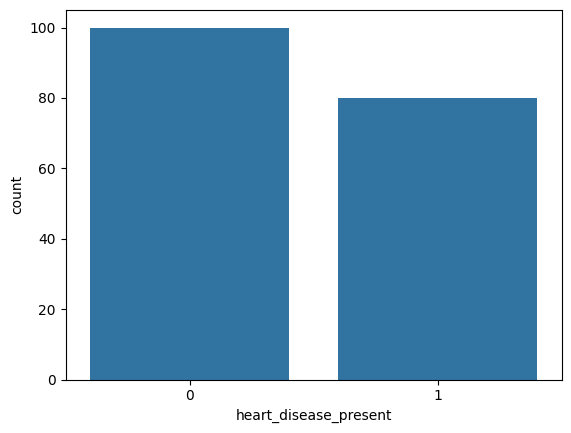

In [ ]:
sns.countplot(x = target)
plt.show()

* •	0 represents no heart disease present
* •	1 represents heart disease present



---
# Imbalance Data
The Target Variable have Imbalanced data so we used the SMOTE Method



In [ ]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [ ]:
# from pandas.core.arrays import categorical
numerical  = ['resting_blood_pressure' , 'serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression' , 'max_heart_rate_achieved','age']
categorical = [c for c in df.columns if c not in (numerical + [target.name])]
categorical

['slope_of_peak_exercise_st_segment',
 'thal',
 'chest_pain_type',
 'num_major_vessels',
 'fasting_blood_sugar_gt_120_mg_per_dl',
 'resting_ekg_results',
 'sex',
 'exercise_induced_angina']

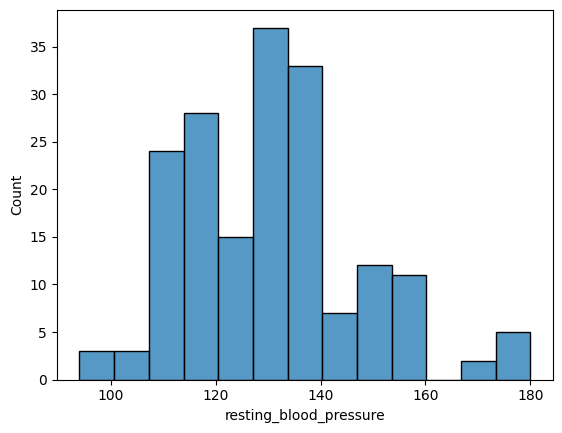

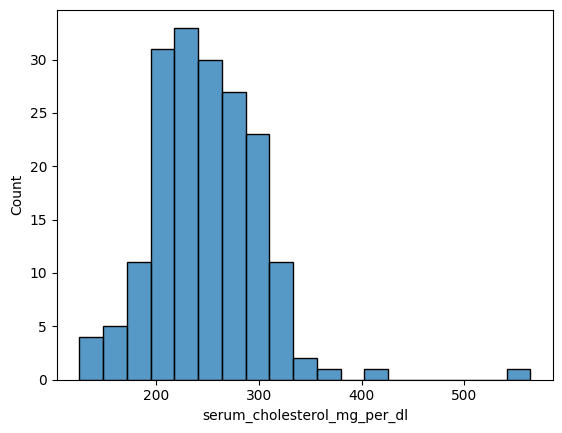

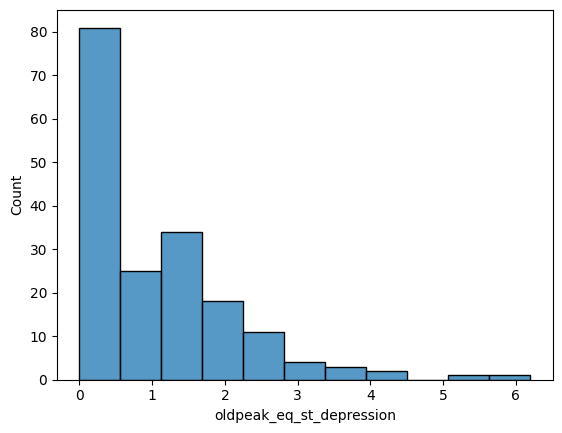

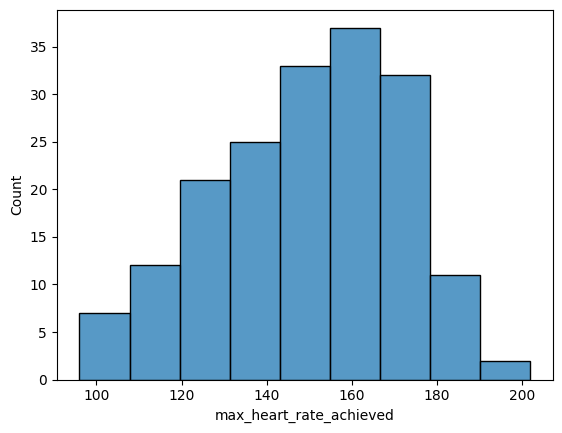

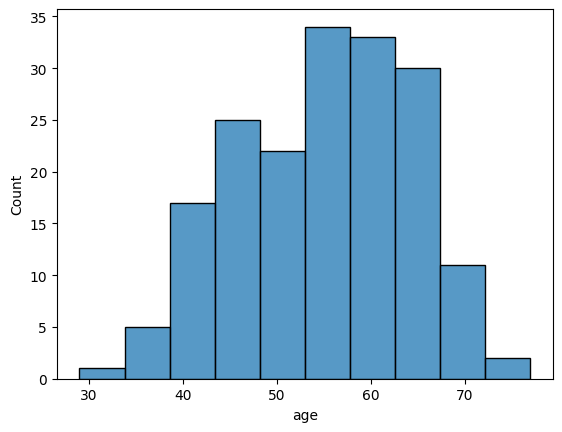

In [ ]:
for i in numerical:
  sns.histplot(df[i])
  plt.show()

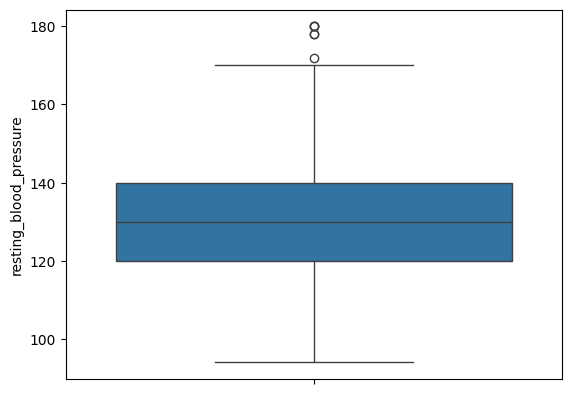

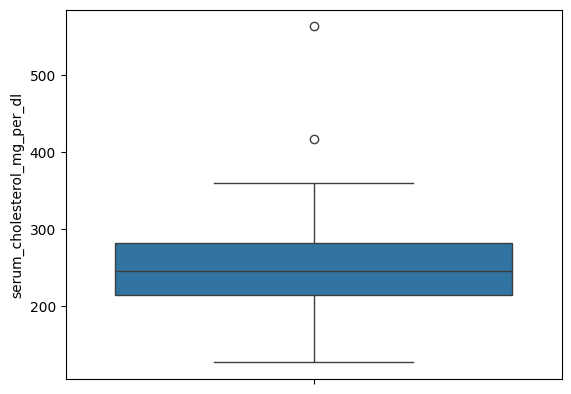

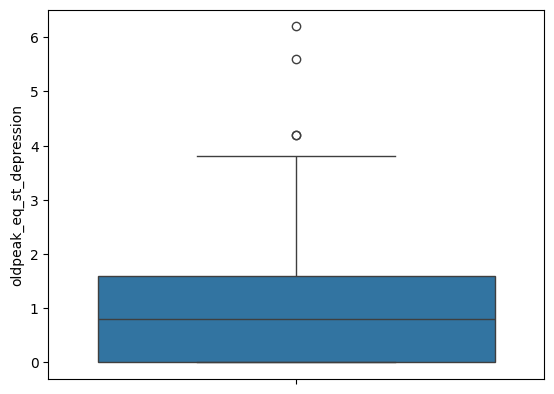

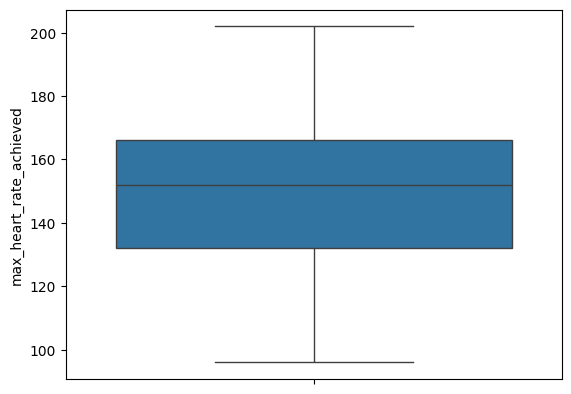

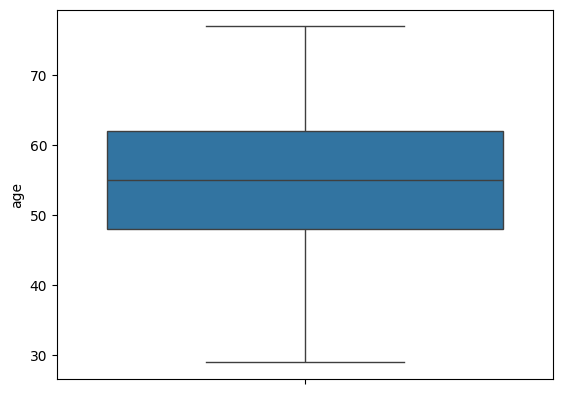

In [ ]:
for i in numerical:
  sns.boxplot(df[i])
  plt.show()

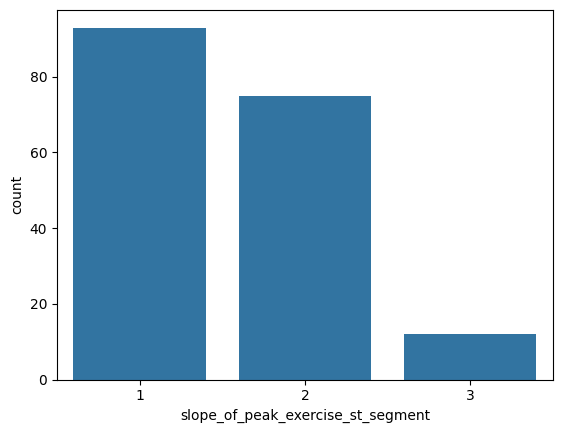

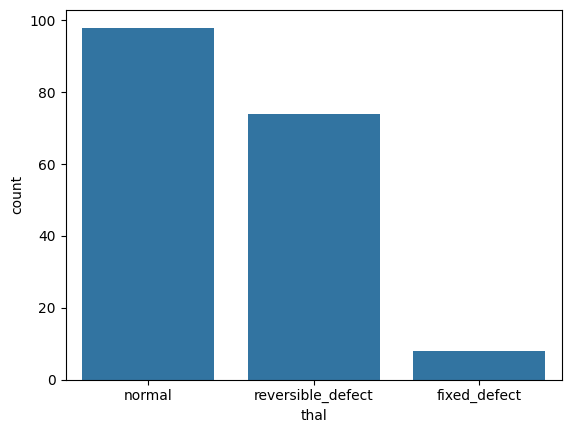

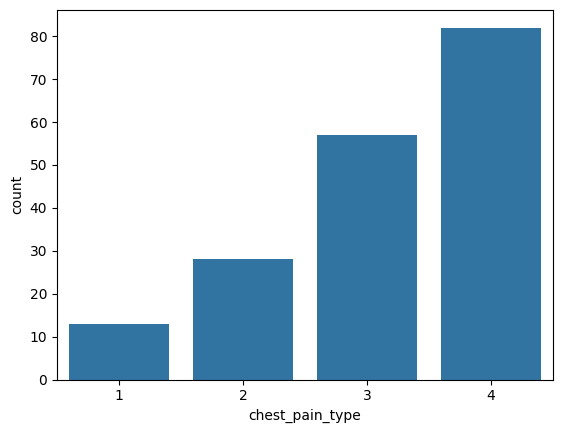

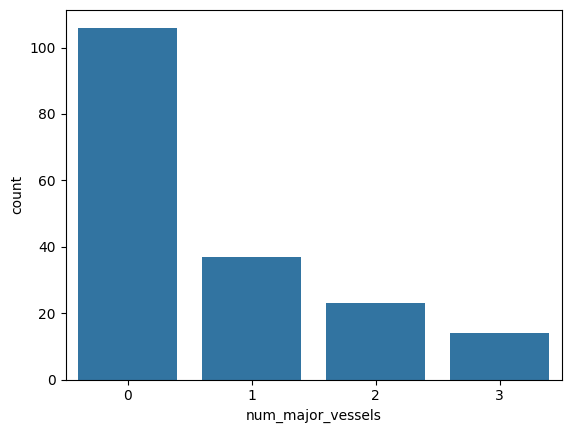

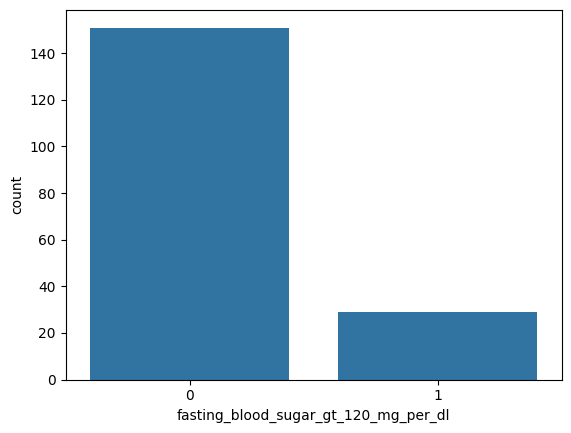

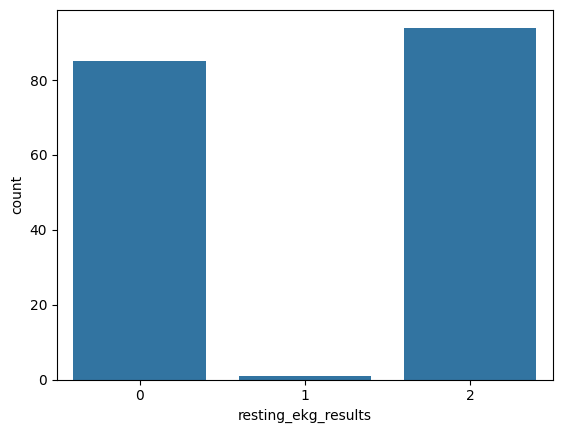

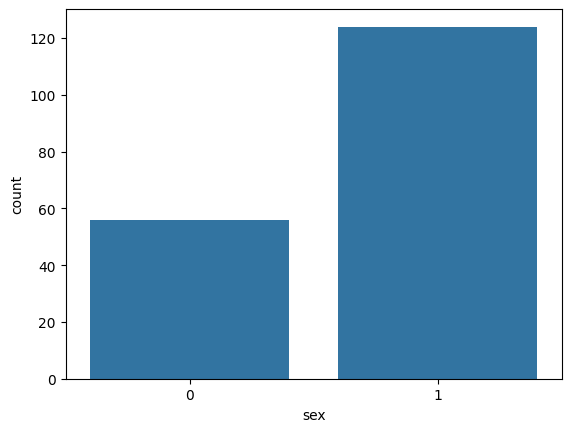

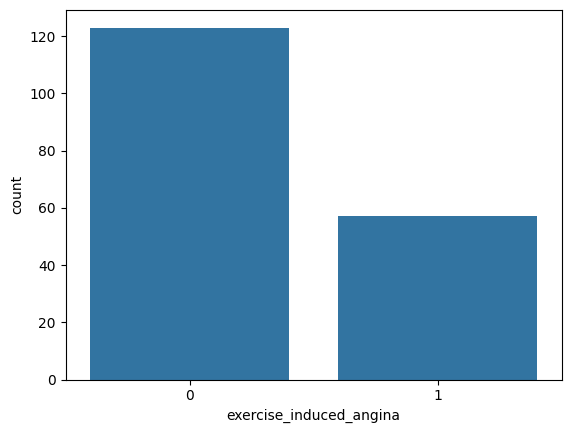

In [ ]:
for i in categorical:
  sns.countplot(x = df[i])
  plt.show()

# Outliers

the dataset is very small (only 180 rows) and contains a few outliers, removing them would lead to loss of valuable information. Therefore, we applied Winsorization (capping method) to limit extreme values at the upper and lower boundaries while preserving all data points

In [ ]:
def Winsorization(col):
  lower = col.quantile(0.01)
  upper = col.quantile(0.99)
  return col.clip(lower,upper)

In [ ]:
for col in numerical:
  df[col] = Winsorization(df[col])

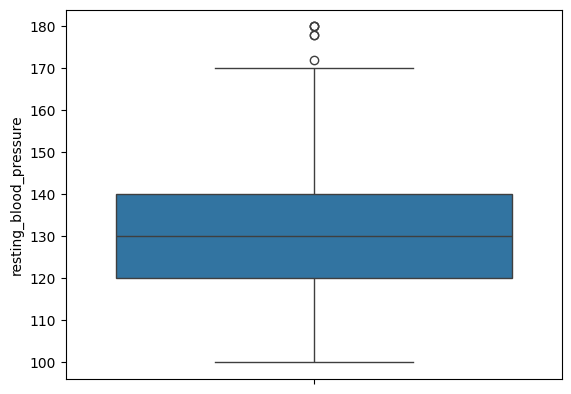

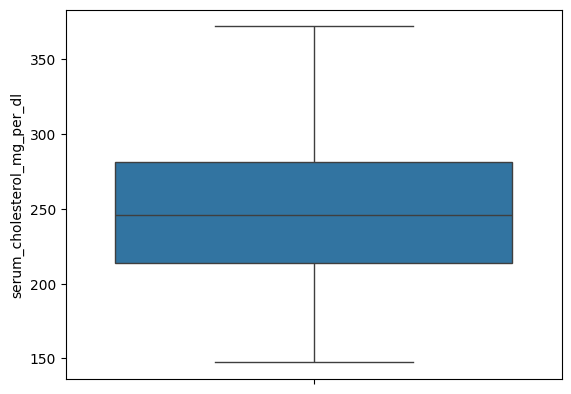

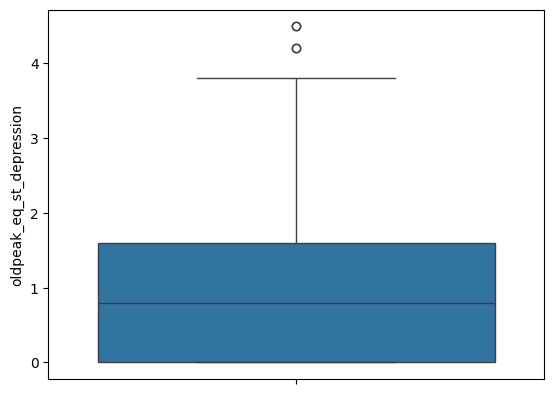

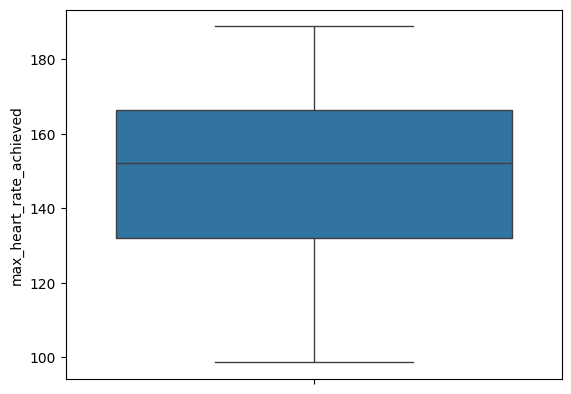

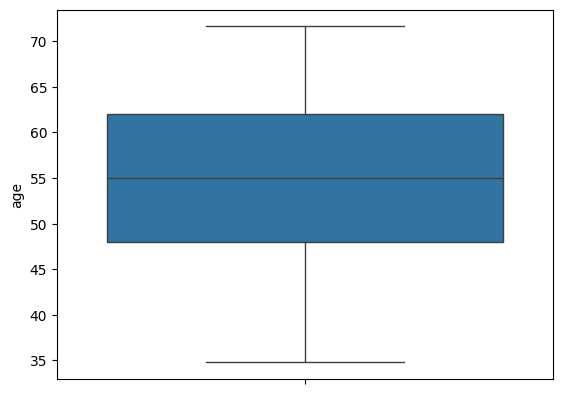

In [ ]:
for i in numerical:
  sns.boxplot(df[i])
  plt.show()

# Correlation

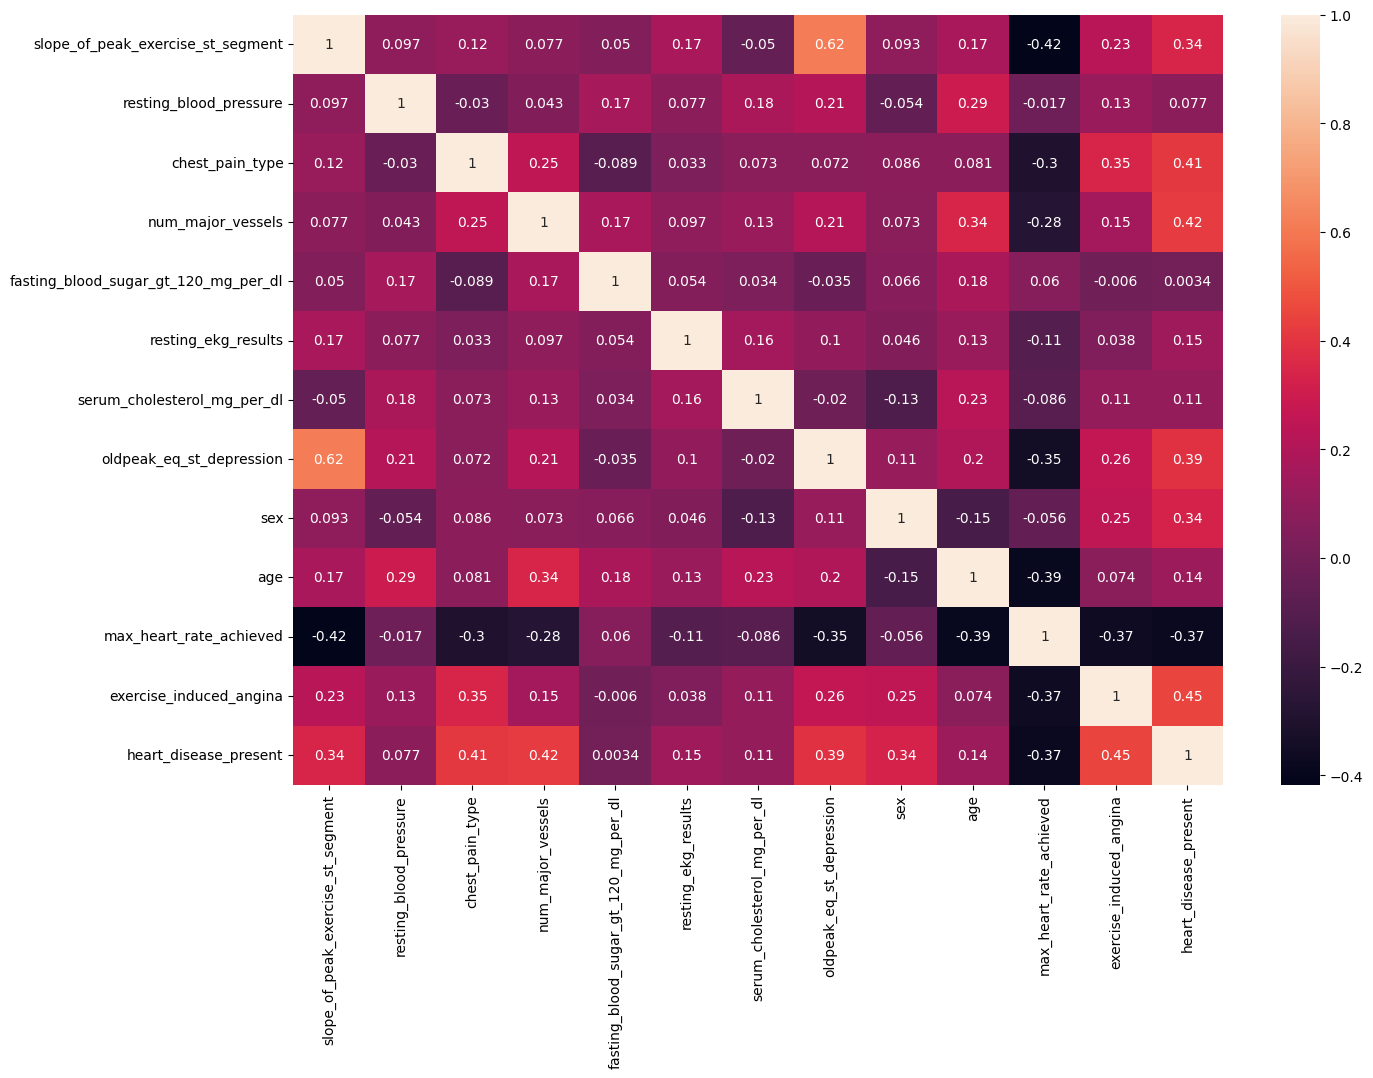

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# Split the data

In [ ]:
y = df['heart_disease_present']
X = df.drop('heart_disease_present',axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

#ColumnTransfer

In [ ]:
scale = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output=False)


In [ ]:
distance_preprocess = ColumnTransformer(
    transformers = [
        ('num' , scale , numerical) ,
        ('cat' , ohe , categorical)
    ]

)

In [ ]:
tree_preprocess = ColumnTransformer(
    transformers= [
        ('cat' , ohe , categorical),
        ('num' , 'passthrough' , numerical)
    ]
)

# Feature Selection

In [ ]:
selector = SelectKBest(score_func=f_classif, k=10)

To identify the most important predictors, we applied the SelectKBest method with an appropriate scoring function and selected the top 10 features based on their highest statistical scores.These features were then used to train the machine learning models.

We Select the 10 top best Features there are:


---


* ['num__oldpeak_eq_st_depression'
* 'num__max_heart_rate_achieved'
* 'cat__thal_normal'
 * 'cat__thal_reversible_defect'
  * 'cat__chest_pain_type_4'
 * 'cat__num_major_vessels_0'
 * 'cat__sex_0'
  * 'cat__sex_1'
 * 'cat__exercise_induced_angina_0'
 * 'cat__exercise_induced_angina_1']

# Training Model

In [ ]:
def evaluate_model(model,y_test,y_pred,y_prob):
  print("\n\n===========================")
  print(f"\n\n Name of Model is {model}")
  print("\n\n===========================")
  print(classification_report(y_test, y_pred))
  print("\n\n===========================")
  acc = accuracy_score(y_test,y_pred)
  prec = precision_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  print(f"Accuracy Score is {acc}")
  print("\n\n===========================")

  cm = confusion_matrix(y_test,y_pred)
  plt.figure(figsize=(5,5))
  sns.heatmap(cm,annot=True,fmt='d' ,cmap='Blues')
  plt.title(model +'- Confusion Matrix')
  plt.tight_layout()
  plt.show()

  fpr ,tpr ,_ = roc_curve(y_test,y_prob)
  roc_auc = auc(fpr,tpr)
  plt.figure(figsize=(5,5))
  plt.plot(fpr,tpr,label=f'AUC = {roc_auc:.3f}')
  plt.plot([0,1],[0,1],'k--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(model +'- ROC Curve')
  plt.tight_layout()
  plt.legend()
  plt.show()



  result.append(
      {
          'Model':model,
          'Accuracy':acc,
          'Precision':prec,
          'F1 Score':f1,
          'Recall' : recall_score(y_test,y_pred)
      }
  )

  return acc, prec, f1

In [ ]:
result = []

# Distance Based Models

In [ ]:
distance_models = {
    "Logistic Regression":LogisticRegression(max_iter=300),
    "KNN":KNeighborsClassifier(),
    "SVM":SVC(probability=True),
    "Navie Bayes":GaussianNB()
}





 Name of Model is Logistic Regression


              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.84      1.00      0.91        16

    accuracy                           0.92        36
   macro avg       0.92      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



Accuracy Score is 0.9166666666666666




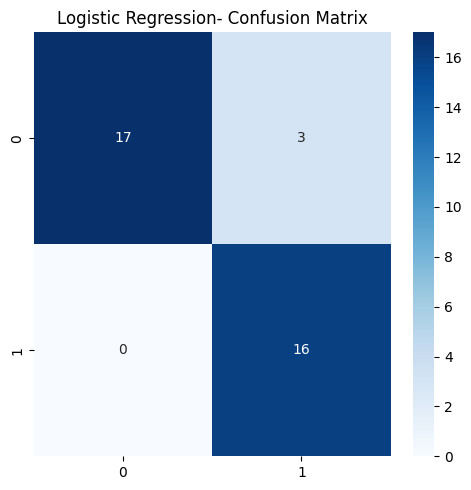

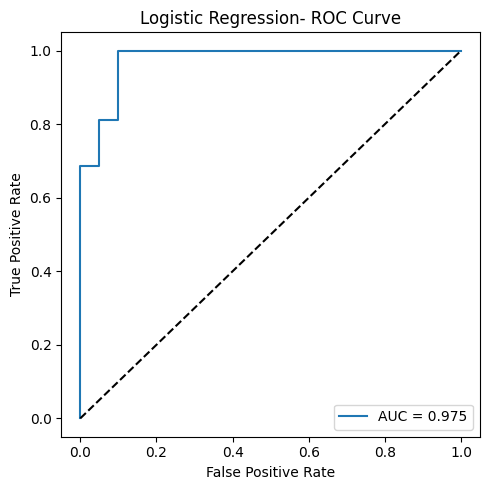

feature_name : ['num__resting_blood_pressure' 'num__serum_cholesterol_mg_per_dl'
 'num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved' 'num__age'
 'cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1']


selected_features : ['num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_

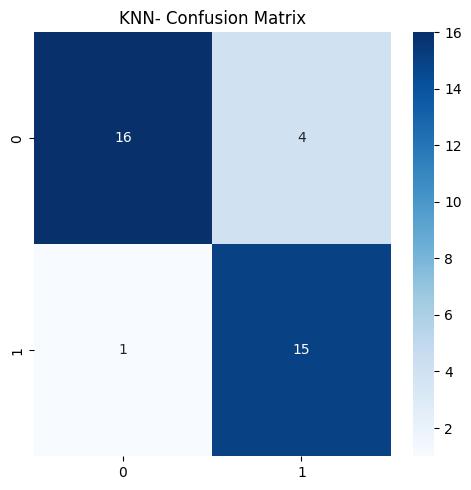

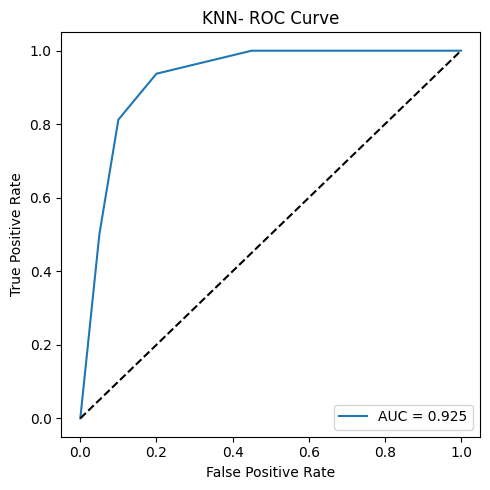

feature_name : ['num__resting_blood_pressure' 'num__serum_cholesterol_mg_per_dl'
 'num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved' 'num__age'
 'cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1']


selected_features : ['num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_

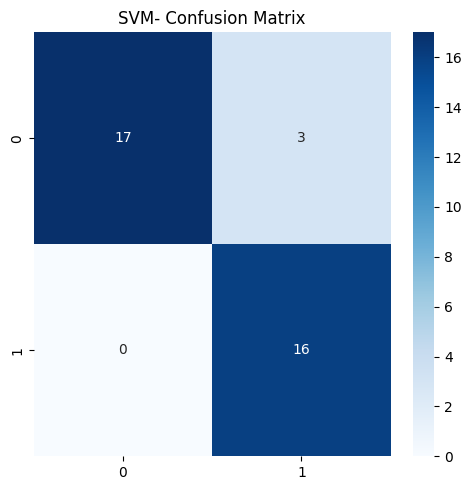

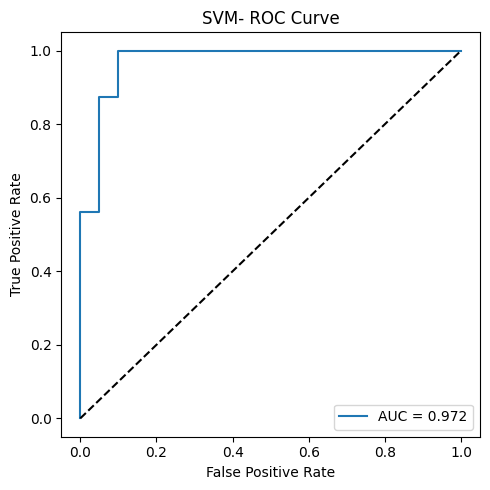

feature_name : ['num__resting_blood_pressure' 'num__serum_cholesterol_mg_per_dl'
 'num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved' 'num__age'
 'cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1']


selected_features : ['num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_

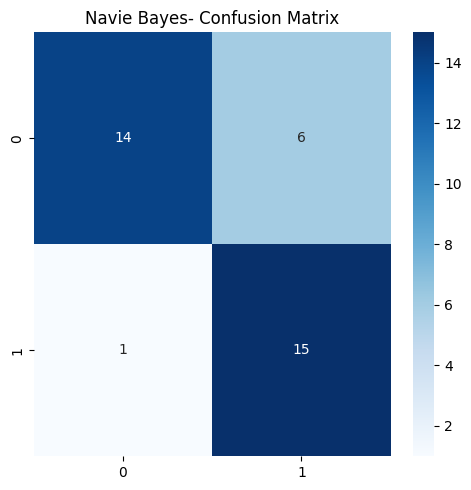

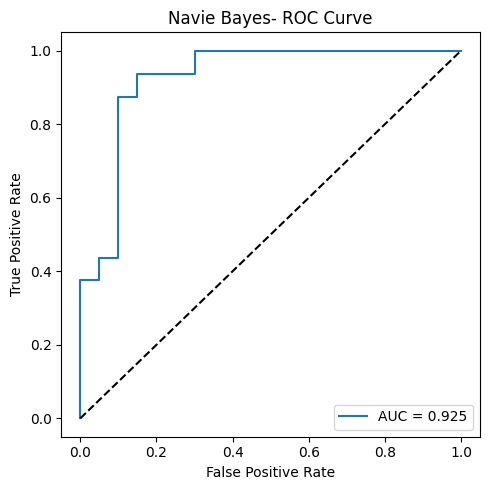

feature_name : ['num__resting_blood_pressure' 'num__serum_cholesterol_mg_per_dl'
 'num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved' 'num__age'
 'cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1']


selected_features : ['num__oldpeak_eq_st_depression' 'num__max_heart_rate_achieved'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_

In [ ]:
for name , model in distance_models.items():
  pipe = ImbPipeline(
     steps =  [
          ('preprocessor',distance_preprocess),
          ('smote',SMOTE(random_state=42)),
          ('selector',selector),
          ('model' , model)
      ]
  )
  pipe.fit(X_train,y_train)
  y_pred = pipe.predict(X_test)
  y_prob = pipe.predict_proba(X_test)[:,1]
  acc, prec, f1 = evaluate_model(name,y_test,y_pred,y_prob)


  # Selected features
  feature_name = pipe.named_steps['preprocessor'].get_feature_names_out()
  print("feature_name :" , feature_name)

  mask = pipe.named_steps['selector'].get_support()
  print("\n\n===========================")
  selected_features = feature_name[mask]
  print("selected_features :" , selected_features)

# Tree based Models

In [ ]:
tree_models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "LightGBM": LGBMClassifier()
}





 Name of Model is Decision Tree


              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.93      0.88      0.90        16

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.92        36
weighted avg       0.92      0.92      0.92        36



Accuracy Score is 0.9166666666666666




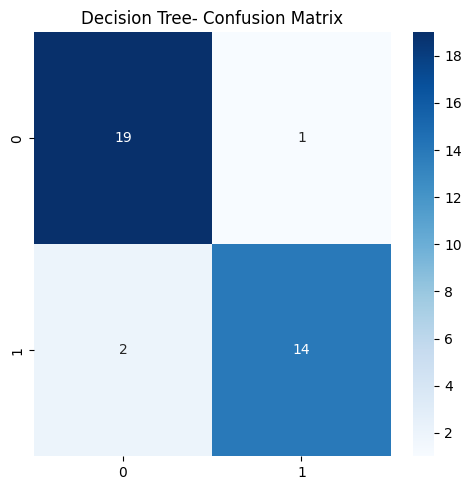

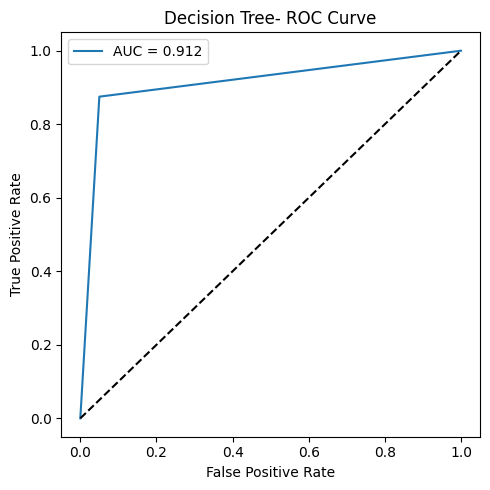

feature_name : ['cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'num__age']


selected_features : ['cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_vessels_0' 'cat__sex_0' 'cat__sex_1'
 'cat__exercise_induced_ang

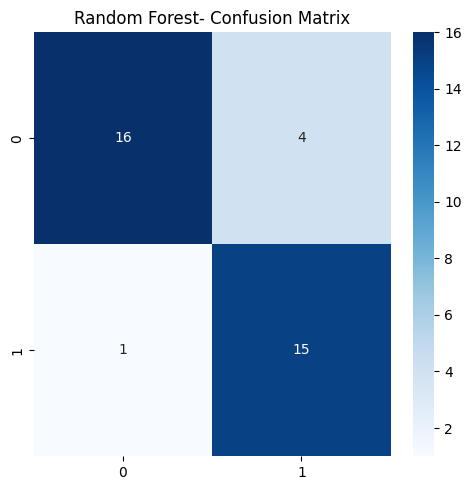

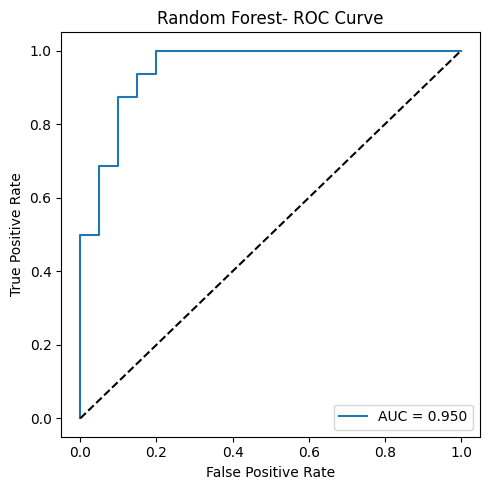

feature_name : ['cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'num__age']


selected_features : ['cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_vessels_0' 'cat__sex_0' 'cat__sex_1'
 'cat__exercise_induced_ang

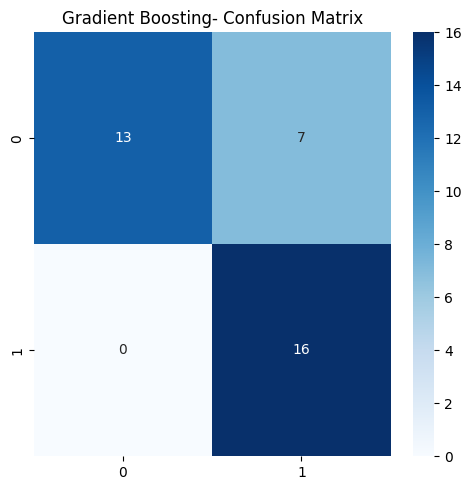

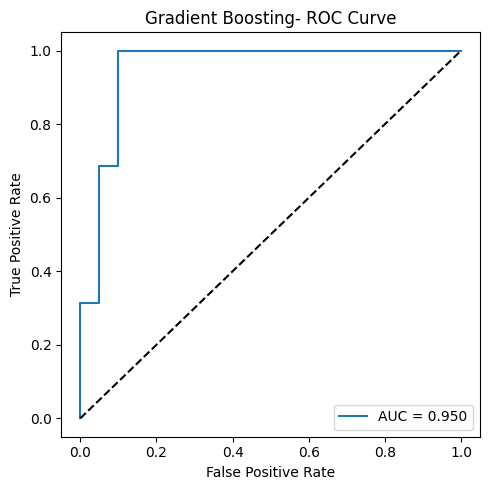

feature_name : ['cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'num__age']


selected_features : ['cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_vessels_0' 'cat__sex_0' 'cat__sex_1'
 'cat__exercise_induced_ang

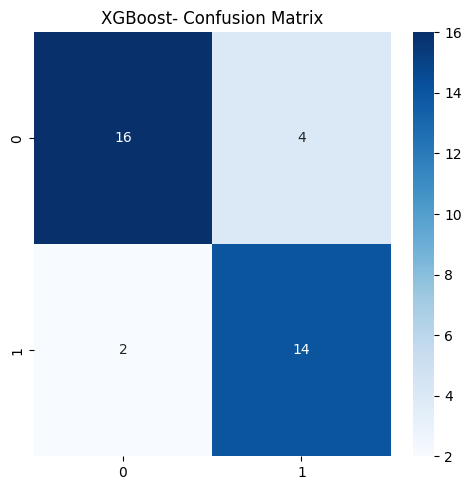

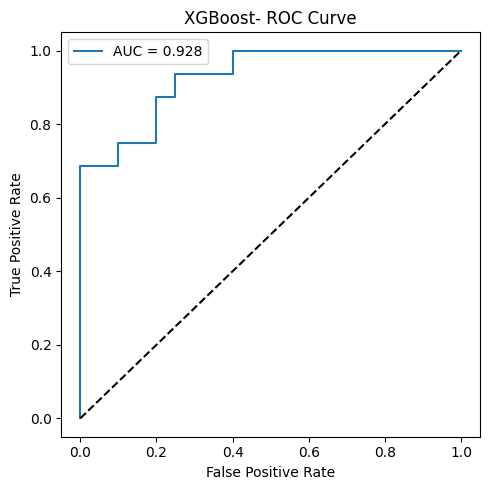

feature_name : ['cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'num__age']


selected_features : ['cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_vessels_0' 'cat__sex_0' 'cat__sex_1'
 'cat__exercise_induced_ang

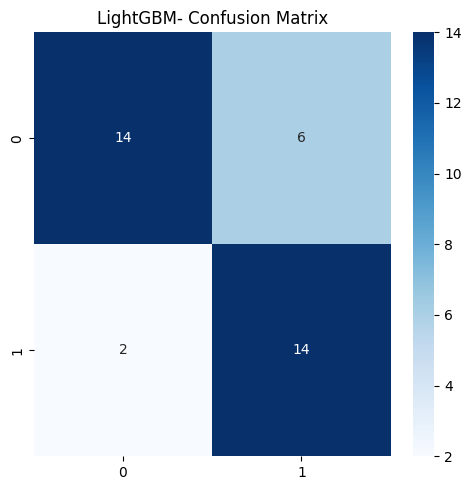

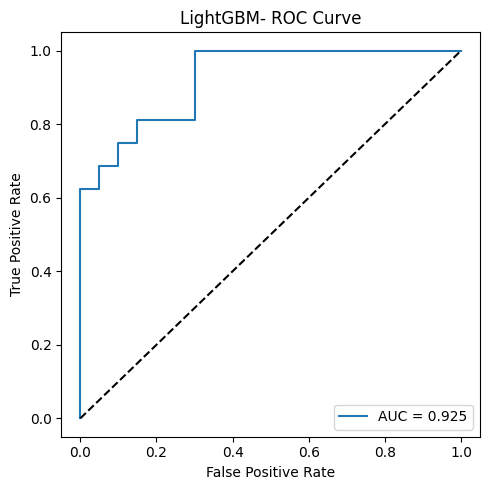

feature_name : ['cat__slope_of_peak_exercise_st_segment_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__thal_fixed_defect'
 'cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_1'
 'cat__chest_pain_type_2' 'cat__chest_pain_type_3'
 'cat__chest_pain_type_4' 'cat__num_major_vessels_0'
 'cat__num_major_vessels_1' 'cat__num_major_vessels_2'
 'cat__num_major_vessels_3' 'cat__fasting_blood_sugar_gt_120_mg_per_dl_0'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_0' 'cat__resting_ekg_results_2' 'cat__sex_0'
 'cat__sex_1' 'cat__exercise_induced_angina_0'
 'cat__exercise_induced_angina_1' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'num__age']


selected_features : ['cat__thal_normal' 'cat__thal_reversible_defect' 'cat__chest_pain_type_4'
 'cat__num_major_vessels_0' 'cat__sex_0' 'cat__sex_1'
 'cat__exercise_induced_ang

In [ ]:
for name, model in tree_models.items():
    pipe = ImbPipeline(steps=[
        ("preprocess", tree_preprocess),
        ("smote", SMOTE(random_state=42)),
        ("selector",selector),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    evaluate_model(name,y_test,y_pred,y_prob)

    # Select featured
    feature_name = pipe.named_steps['preprocess'].get_feature_names_out()
    print("feature_name :" , feature_name)

    mask = pipe.named_steps['selector'].get_support()
    print("\n\n===========================")
    selected_features = feature_name[mask]
    print("selected_features :" , selected_features)

In [ ]:
result_df = pd.DataFrame(result)
result_df.sort_values('Accuracy',ascending=False)

,Model,Accuracy,Precision,F1 Score,Recall
0,Logistic Regression,0.916667,0.842105,0.914286,1.0000
2,SVM,0.916667,0.842105,0.914286,1.0000
4,Decision Tree,0.916667,0.933333,0.903226,0.8750
1,KNN,0.861111,0.789474,0.857143,0.9375
5,Random Forest,0.861111,0.789474,0.857143,0.9375
7,XGBoost,0.833333,0.777778,0.823529,0.8750
3,Navie Bayes,0.805556,0.714286,0.810811,0.9375
6,Gradient Boosting,0.805556,0.695652,0.820513,1.0000
8,LightGBM,0.777778,0.700000,0.777778,0.8750


# Hyperparameter Tuning the params

In [ ]:
param_grids = {

    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"]
    },

    "Navie Bayes": {
        "model__var_smoothing": [1e-09, 1e-08, 1e-07]
    },

    "Decision Tree": {
        "model__max_depth": [3, 5, 7, None],
        "model__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5, 7, None],
        "model__min_samples_split": [2, 5]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1, 0.2]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [-1, 3, 5],
        "model__learning_rate": [0.05, 0.1]
    }
}

In [ ]:
result_tune = []

In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [ ]:
from scipy.stats import scoreatpercentile
def model_tune(name,model,preprocessor):
  print(f"the Model Name {name}")
  pipe = ImbPipeline(
      steps = [
          ('preprocessor',preprocessor),
          ('smote',SMOTE(random_state=42)),
          ('selector',selector),
          ('model',model)
      ])
  grid = GridSearchCV(pipe,param_grids[name],cv=cv,verbose=1,n_jobs=-1,scoring='accuracy')
  grid.fit(X_train,y_train)
  print("\n\n===========================")
  print(f"Best params : {grid.best_params_}")
  print("\n\n===========================")
  print(f"Best Score : {grid.best_score_}")
  print("\n\n===========================")
  best_estimator = grid.best_estimator_
  y_pred_grid = best_estimator.predict(X_test)
  y_prob_grid = best_estimator.predict_proba(X_test)[:,-1]
  result_tune.append(
      {
          'Model':name,
          'Accuracy':accuracy_score(y_test,y_pred_grid),
          'Precision':precision_score(y_test,y_pred_grid),
          'F1 Score':f1_score(y_test,y_pred_grid),
          'Recall' : recall_score(y_test,y_pred_grid)
      }
  )

In [ ]:
for name,model in distance_models.items():
  model_tune(name,model,distance_preprocess)

the Model Name Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits


Best params : {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


Best Score : 0.8199507389162562


the Model Name KNN
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best params : {'model__n_neighbors': 9, 'model__weights': 'uniform'}


Best Score : 0.7849753694581281


the Model Name SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best params : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


Best Score : 0.8059113300492611


the Model Name Navie Bayes
Fitting 5 folds for each of 3 candidates, totalling 15 fits


Best params : {'model__var_smoothing': 1e-09}


Best Score : 0.777832512315271




In [ ]:
for name, model in tree_models.items():
    model_tune(name, model,tree_preprocess)

the Model Name Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best params : {'model__max_depth': 3, 'model__min_samples_split': 2}


Best Score : 0.7571428571428571


the Model Name Random Forest
Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params : {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}


Best Score : 0.8059113300492611


the Model Name Gradient Boosting
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best params : {'model__learning_rate': 0.05, 'model__n_estimators': 100}


Best Score : 0.7985221674876847


the Model Name XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


Best Score : 0.8123152709359607


the Model Name LightGBM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 80, number of negative: 80
[LightG

In [ ]:
results_df1 = pd.DataFrame(
    result_tune,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)
results_df1.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.916667,0.882353,0.9375,0.909091
7,XGBoost,0.916667,0.842105,1.0000,0.914286
2,SVM,0.916667,0.842105,1.0000,0.914286
0,Logistic Regression,0.888889,0.800000,1.0000,0.888889
5,Random Forest,0.861111,0.761905,1.0000,0.864865
6,Gradient Boosting,0.861111,0.761905,1.0000,0.864865
3,Navie Bayes,0.805556,0.714286,0.9375,0.810811
8,LightGBM,0.805556,0.714286,0.9375,0.810811
4,Decision Tree,0.777778,0.700000,0.8750,0.777778


# Comparison of models

In [ ]:
model =result_df['Model']
acc = result_df['Accuracy']

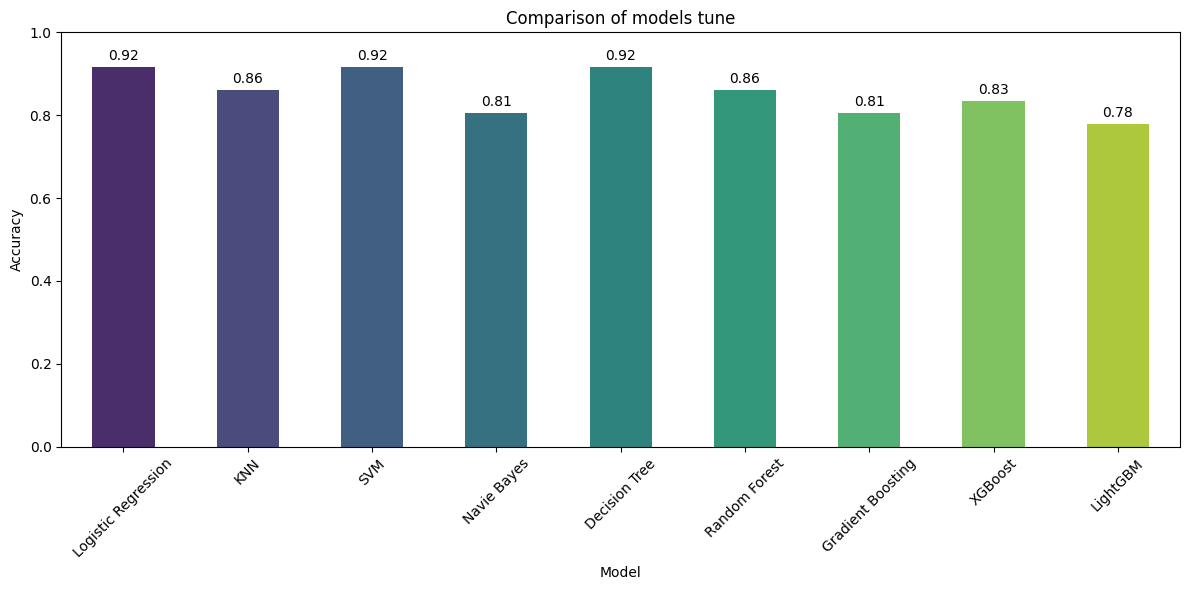

In [ ]:
plt.figure(figsize=(12,6))
bar_plot = sns.barplot(x=model,y=acc,width=0.5,palette='viridis')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.title('Comparison of models tune')
for i , v in enumerate(acc):
  bar_plot.text(i , v+ 0.01, f"{v:.2f}",ha ='center' ,va='bottom',fontsize=10)

plt.tight_layout()
plt.show()

# Comparison of models after tune

In [ ]:
model1 = results_df1['Model']
Acc = results_df1['Accuracy']

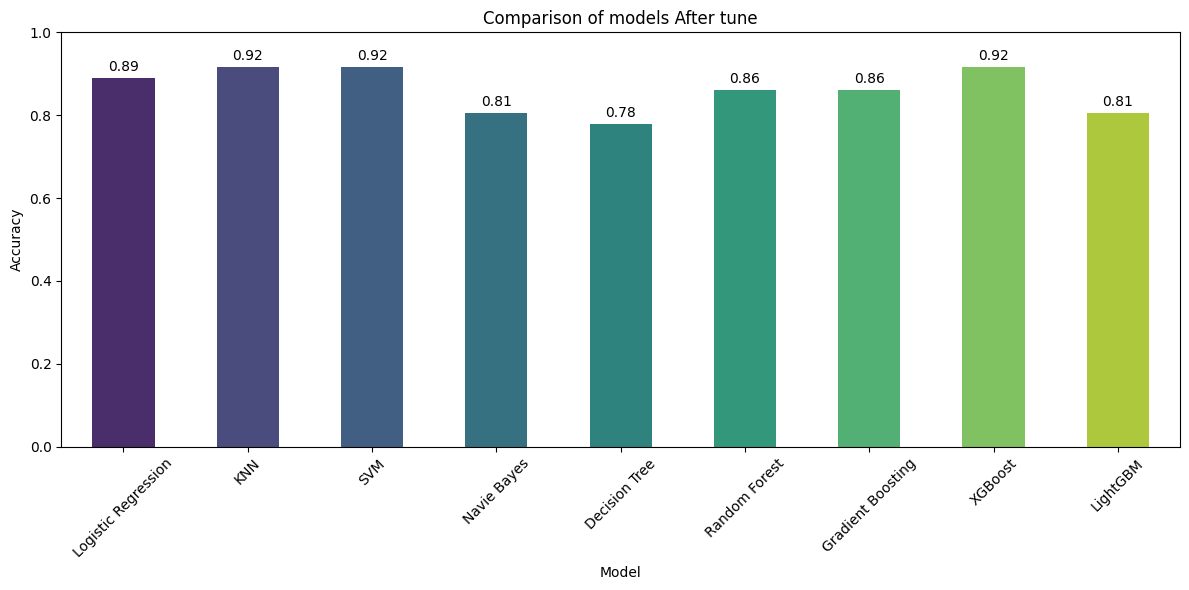

In [ ]:
plt.figure(figsize=(12,6))
bar_plot = sns.barplot(x=model1,y=Acc,width=0.5,palette='viridis')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.title('Comparison of models After tune')
for i , v in enumerate(Acc):
  bar_plot.text(i , v+ 0.01, f"{v:.2f}",ha ='center' ,va='bottom',fontsize=10)

plt.tight_layout()
plt.show()

# Model Comparison Report

* **Using K-Nearest Neighbors (KNN), we achieved the highest overall performance with 92% accuracy and the best F1 Score (0.909), making it the most effective model for predicting heart disease in this dataset.**

* **SVM and XGBoost also achieved 92% accuracy with strong recall (1.0), but KNN outperformed them in precision and F1 Score, giving a better balance between false positives and false negatives.**

* **Before tuning, Logistic Regression, SVM, and Decision Tree showed strong baseline performance (all around 92%), indicating the dataset is suitable for linear and non-linear models.**

* **After tuning, KNN showed the most stable improvement across all metrics, demonstrating strong generalization on the small dataset.**

* **Therefore, KNN was finalized as the best model for heart disease prediction due to its balanced accuracy, high recall, and superior F1 Score compared to other models.**

#  Report on Challenges Faced

### **1. Separate Feature and Target Files*

**Problem:**
The dataset was provided in two different files — one containing features and the other containing target labels.

**Solution:**
Merged both files carefully using pandas and verified correct row alignment.

**Why:**
Incorrect alignment between features and labels can lead to completely wrong model learning.


---


### **2. Imbalanced Dataset*

**Problem:**
The dataset had an unequal distribution between positive and negative heart disease cases.

**Solution:**
Used SMOTE, class weights, and evaluated models using precision, recall, F1-score, not just accuracy.

**Why:**
Imbalanced data can cause the model to be biased toward the majority class and miss important minority cases.


---


### *3. Small Dataset (Only 180 Rows)*

**Problem:**
The dataset size was very small, increasing the risk of overfitting and unstable model performance.

**Solution:**
Applied robust preprocessing, cross-validation, and focused on careful model tuning.

**Why:**
Small datasets require stricter validation, otherwise results may not generalize well.

---

### *4. Presence of Outliers*

**Problem:**
Medical features contained extreme values that could negatively influence model training.

**Solution:**
Applied Winsorization (Capping Method) to cap extreme values at upper and lower boundaries.

**Why:**
This preserves medically meaningful information while minimizing the effect of extreme values.

---

### *5. No Correlated Features*

**Problem:**
Correlation matrix showed no highly correlated features, unlike typical clinical datasets.

**Solution:**
Did not drop any features based on correlation and proceeded with other selection methods.

**Why:**
Removing features without correlation issues is unnecessary and may lose important signals.

---

### *6. Increased Feature Count After One-Hot Encoding*

**Problem:**
After applying One-Hot Encoding to categorical variables, the number of columns increased significantly, causing dimensionality issues.

**Solution:**
Used SelectKBest (mutual_info_classif) to select the top 10 most informative features.

**Why:**
Higher-dimensional data can reduce model performance; feature selection helps keep only the most relevant predictors.

#  Suggestions for Heart Patients

### 1. *Regular Health Monitoring*

* Check blood pressure, cholesterol (LDL, HDL), triglycerides, and blood sugar frequently.

* Perform routine ECG, ECHO, and stress tests if recommended.

* Early monitoring helps prevent heart attacks and stroke.

### 2. *Maintain a Heart-Healthy Lifestyle*

* Follow a low-salt, low-fat, and high-fiber diet.

* Include fruits, vegetables, whole grains, and omega-3 rich foods (fish, nuts).

* Engage in regular physical activity (30-minute walk per day).

* Avoid smoking and limit alcohol.

### 3. *Medical Consultation & Medication*

* Consult a cardiologist if symptoms like chest pain, shortness of breath, dizziness, or irregular heartbeat occur.

* Take prescribed medicines regularly: BP tablets, blood thinners, statins, or other cardiac medications.

* Do not skip doses or self-medicate.

### 4. *Stress & Lifestyle Management*

* Reduce stress through yoga, meditation, or deep-breathing exercises.

* Maintain a healthy weight to reduce strain on the heart.

* Ensure 7–8 hours of proper sleep daily.

### 5. *Preventive Measures*

* Control conditions like diabetes, hypertension, obesity, and cholesterol.

* Maintain a heart-friendly routine, even if symptoms improve.

* Stay updated with routine checkups to detect early warning signs.

# Project Summary

* The dataset had no missing values, no duplicates, and no highly correlated features, which made preprocessing simple and clean.

* The data contained outliers, so Winsorization (capping) was applied to reduce their impact while still preserving important clinical information.

* The dataset was very small (180 rows) and imbalanced, making model evaluation more difficult and increasing the risk of overfitting.

* After One-Hot Encoding, the number of features increased significantly, so SelectKBest was used to keep only the top 10 important features.

* Multiple machine learning models were tested — Logistic Regression, SVM, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, and Naive Bayes.

* After tuning, K-Nearest Neighbors (KNN) delivered the best overall performance with
Accuracy: 0.9167, Precision: 0.8823, Recall: 0.9375, and F1 Score: 0.9091, making it the top model for heart disease prediction.

* The project proves that with proper preprocessing, feature selection, and model tuning, even a small and imbalanced medical dataset can produce strong and reliable predictive results — with KNN emerging as the most balanced and effective model.

# ⚠️ Important
* The dataset was very small (180 rows) and imbalanced, which increases the chance of overfitting and reduces model generalization.

* The data contained outliers, so Winsorization (capping) was used to reduce their impact while preserving important medical information.

* After One-Hot Encoding, feature count increased, so SelectKBest was applied to choose the top 10 important features for better model performance.